In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [18]:
df = pd.read_csv('./data/titanic.csv')
df.sample(20)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
800,801,0,2,"Ponesell, Mr. Martin",male,34.0,0,0,250647,13.0000,NaN,S
199,200,0,2,"Yrois, Miss. Henriette (""Mrs Harbeck"")",female,24.0,0,0,248747,13.0000,NaN,S
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,B19,S
585,586,1,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.6500,E68,S
325,326,1,1,"Young, Miss. Marie Grice",female,36.0,0,0,PC 17760,135.6333,C32,C
536,537,0,1,"Butt, Major. Archibald Willingham",male,45.0,0,0,113050,26.5500,B38,S
236,237,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S
388,389,0,3,"Sadlier, Mr. Matthew",male,NaN,0,0,367655,7.7292,NaN,Q
160,161,0,3,"Cribb, Mr. John Hatfield",male,44.0,0,1,371362,16.1000,NaN,S
586,587,0,2,"Jarvis, Mr. John Denzil",male,47.0,0,0,237565,15.0000,NaN,S


In [19]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


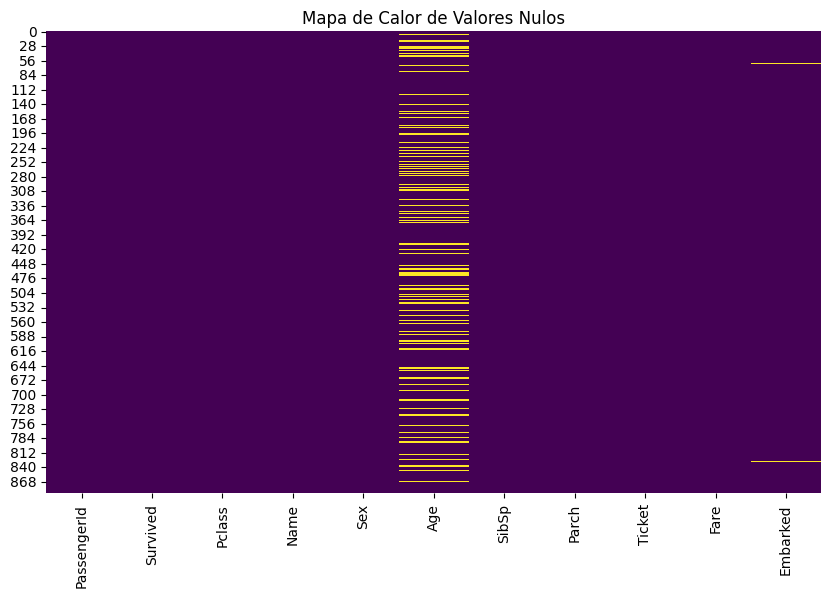

In [33]:
# Suponiendo que tu dataframe se llama 'df'
if 'df' not in globals():
    df = pd.read_csv('./data/titanic.csv')

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos')

# Guardar el gráfico como un archivo PNG
plt.savefig('output.png', format='png')

# Mostrar el gráfico
plt.show()

In [32]:
missing_values_percentage = df.isnull().mean() * 100
missing_values_percentage = missing_values_percentage.round(2).sort_values(ascending=False)
print(missing_values_percentage)

Age            19.87
Embarked        0.22
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
dtype: float64


In [8]:
df_titanic = pd.read_csv('./data/titanic.csv')
total_valores_faltantes = df_titanic.isnull().sum().sum()
print(f"Total de valores faltantes (null) en titanic.csv: {total_valores_faltantes}")

Total de valores faltantes (null) en titanic.csv: 866


In [21]:
tabla_nulos = (
    df_titanic.isnull().sum()
    .rename('Valores_faltantes')
    .to_frame()
    .assign(Porcentaje=lambda t: (t['Valores_faltantes'] / len(df_titanic) * 100).round(2))
    .query('Valores_faltantes > 0')
    .sort_values('Valores_faltantes', ascending=False)
)

display(
    tabla_nulos.style
    .background_gradient(subset=['Valores_faltantes', 'Porcentaje'], cmap='viridis')
    .format({'Porcentaje': '{:.2f}%'})
    .set_caption('Tabla de valores faltantes por columna (Titanic)')
)

,Valores_faltantes,Porcentaje
Cabin,687,77.10%
Age,177,19.87%
Embarked,2,0.22%


In [22]:
df.drop(columns=['Cabin'], inplace=True, errors='ignore')
print("Columna 'Cabin' eliminada.")

Columna 'Cabin' eliminada.


In [37]:
# calcula la mediana de la columna 'Age'
age_median = df['Age'].median()
print(f"Mediana de 'Age': {age_median}")

# rellenar valores nulos de Age con la mediana
df['Age'] = df['Age'].fillna(age_median)
print("Valores nulos de 'Age' rellenados con la mediana.")

Mediana de 'Age': 28.0
Valores nulos de 'Age' rellenados con la mediana.


In [38]:
# rellenar valores nulos con la moda
moda_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(moda_embarked)
print("Valores nulos de 'Embarked' rellenados con la moda.")

Valores nulos de 'Embarked' rellenados con la moda.


In [36]:
round(df.isnull().sum().sort_values(ascending = False) / len(df) * 100, 2)

Age            19.87
Embarked        0.22
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
dtype: float64